检测到 3 个中枢区域:
  中枢1: 3614.728 [3613.087 - 3615.130], 穿越K线: 23
  中枢2: 3634.494 [3633.481 - 3635.630], 穿越K线: 27
  中枢3: 3651.577 [3650.714 - 3652.857], 穿越K线: 7


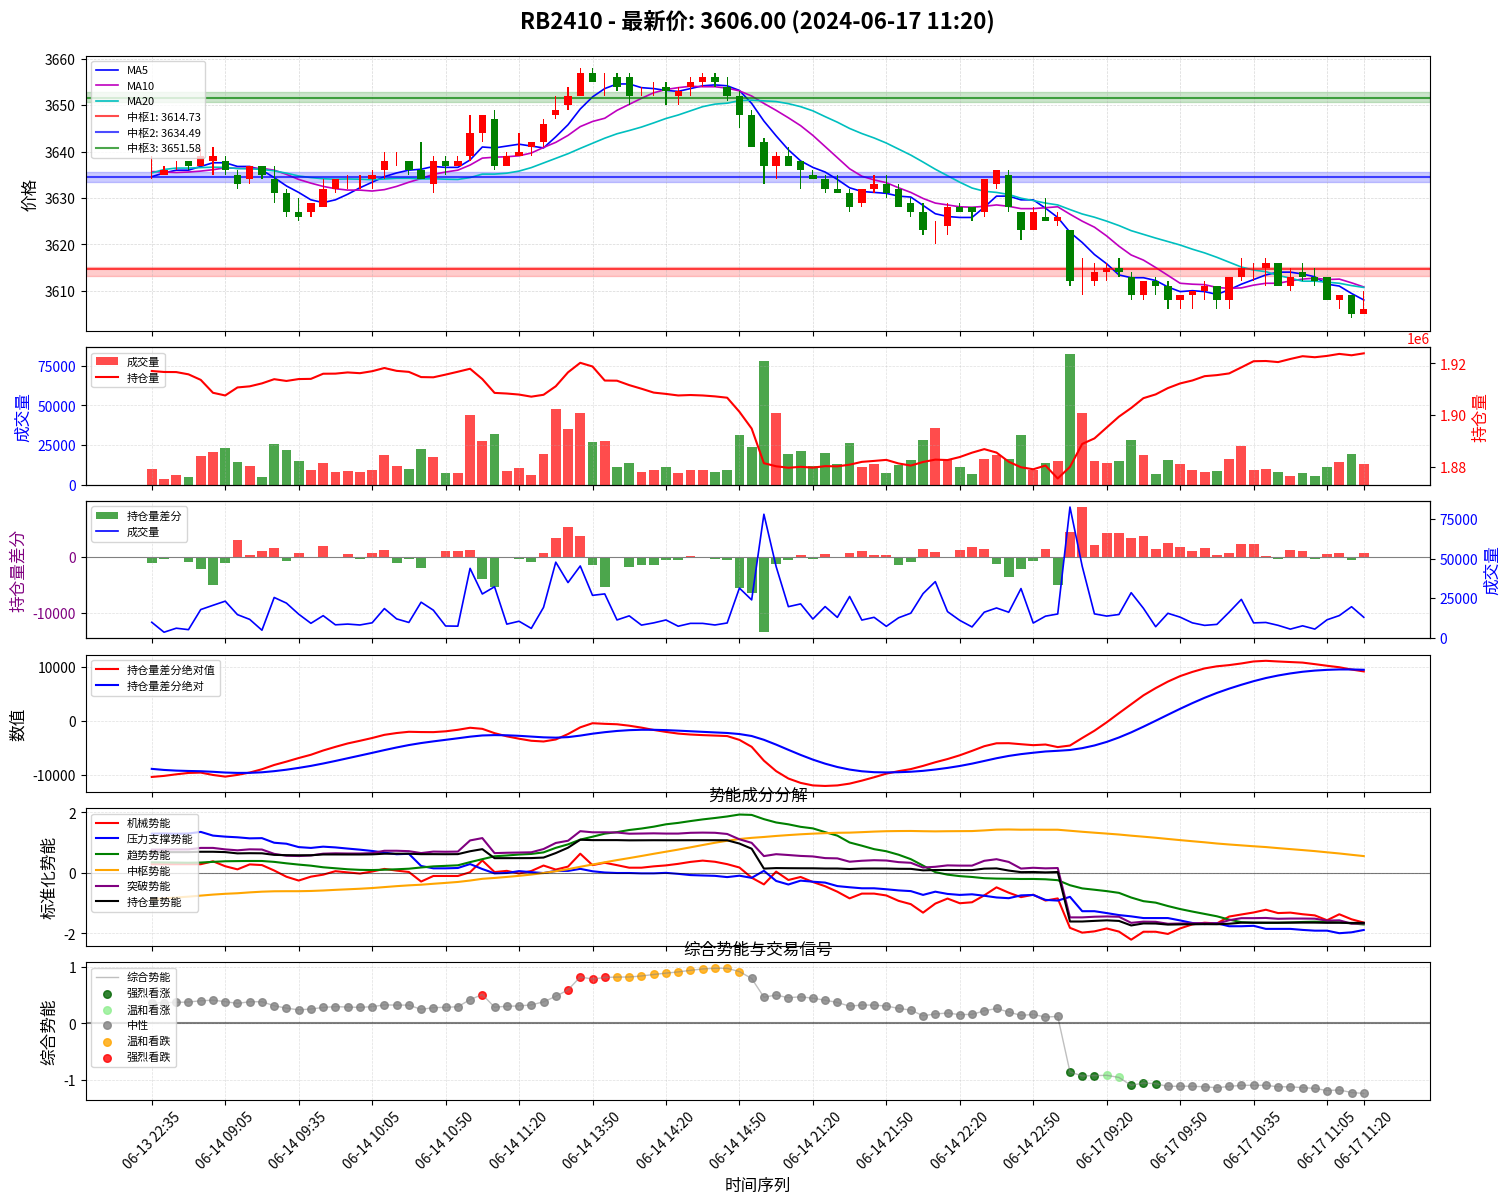

RB2410 当前市场分析报告

1. 价格位置分析:
   当前价格: 3606.000
   相对于中枢1(3614.728): 下方 0.20%
   相对于中枢2(3634.494): 下方 0.76%
   相对于中枢3(3651.577): 下方 1.24%

2. 势能状态:
   综合势能: -1.2336
   势能水平: 极低
   势能趋势: 平稳
   交易信号: 中性

3. 势能成分:
   机械势能: -1.6424
   压力支撑: -1.8861
   趋势势能: -1.7039
   中枢势能: 0.5555
   突破势能: -1.6691
   持仓量势能: -1.6504

4. 操作建议:
   ⚪ 保持观望 - 势能中性，等待明确信号


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import argrelextrema
from sklearn.cluster import KMeans
import warnings
import talib
warnings.filterwarnings('ignore')

class KLineCenterAnalyzer:
    def __init__(self, window=5, shadow_ratio=0.7, min_zone_separation=0.02, 
                 max_zone_width_ratio=0.1, entity_size_threshold=0.05):
        self.window = window
        self.shadow_ratio = shadow_ratio
        self.min_zone_separation = min_zone_separation
        self.max_zone_width_ratio = max_zone_width_ratio
        self.entity_size_threshold = entity_size_threshold
    
    def is_bullish(self, open_price, close_price):
        """判断是否为阳线"""
        return close_price >= open_price
    
    def calculate_shadow_ratio(self, open_price, high_price, low_price, close_price):
        """计算影线比例"""
        body_size = abs(close_price - open_price)
        upper_shadow = high_price - max(open_price, close_price)
        lower_shadow = min(open_price, close_price) - low_price
        
        if body_size == 0:
            return upper_shadow, lower_shadow, 0
        
        return upper_shadow, lower_shadow, max(upper_shadow, lower_shadow) / body_size
    
    def find_reversal_points(self, df):
        """寻找K线反转点"""
        reversal_points = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        for i in range(1, len(opens)-1):
            # 检查颜色反转
            prev_bullish = self.is_bullish(opens[i-1], closes[i-1])
            curr_bullish = self.is_bullish(opens[i], closes[i])
            next_bullish = self.is_bullish(opens[i+1], closes[i+1])
            
            # 颜色反转点
            if (prev_bullish != curr_bullish) or (curr_bullish != next_bullish):
                reversal_points.append(('color_reversal', i, closes[i]))
            
            # 检查影线反转
            _, _, ratio_curr = self.calculate_shadow_ratio(
                opens[i], highs[i], lows[i], closes[i])
            
            # 影线比例超过阈值，可能是反转点
            if ratio_curr > self.shadow_ratio:
                upper_shadow, lower_shadow, _ = self.calculate_shadow_ratio(
                    opens[i], highs[i], lows[i], closes[i])
                
                if upper_shadow > lower_shadow:
                    reversal_points.append(('upper_shadow', i, highs[i]))
                else:
                    reversal_points.append(('lower_shadow', i, lows[i]))
        
        return reversal_points
    
    def find_volume_price_points(self, df):
        """寻找成交量极值点对应的K线价格"""
        volumes = df['volume'].values
        closes = df['close'].values
        
        # 寻找成交量局部高点
        volume_high_idx = argrelextrema(volumes, np.greater, order=self.window)[0]
        
        volume_points = []
        for idx in volume_high_idx:
            volume_points.append(('volume_price', idx, closes[idx]))
        
        return volume_points
    
    def cluster_prices(self, points, n_clusters=3):
        """对价格点进行聚类，返回聚类中心"""
        if not points:
            return []
            
        prices = np.array([point[2] for point in points]).reshape(-1, 1)
        
        if len(prices) <= n_clusters:
            return sorted([p[0] for p in prices])
        
        kmeans = KMeans(n_clusters=min(n_clusters, len(prices)), random_state=0).fit(prices)
        centers = sorted([center[0] for center in kmeans.cluster_centers_])
        return centers
    
    def find_centers(self, df):
        """找出中枢水平线"""
        reversal_points = self.find_reversal_points(df)
        volume_points = self.find_volume_price_points(df)
        
        all_points = reversal_points + volume_points
        
        if not all_points:
            return [], [], []
        
        center_lines = self.cluster_prices(all_points, 3)
        
        return center_lines, reversal_points, volume_points
    
    def calculate_center_zones(self, df, center_lines):
        """计算中枢区域，确保不重叠"""
        center_zones = []
        opens = df['open'].values
        highs = df['high'].values
        lows = df['low'].values
        closes = df['close'].values
        
        price_range = np.max(highs) - np.min(lows)
        min_separation = price_range * self.min_zone_separation
        max_zone_width = price_range * self.max_zone_width_ratio
        
        entity_sizes = np.abs(closes - opens)
        entity_size_threshold = np.percentile(entity_sizes, 95)
        
        for center_line in center_lines:
            crossing_k_lines = []
            for i in range(len(df)):
                if lows[i] <= center_line <= highs[i]:
                    entity_high = max(opens[i], closes[i])
                    entity_low = min(opens[i], closes[i])
                    entity_size = entity_high - entity_low
                    
                    if entity_size <= entity_size_threshold:
                        crossing_k_lines.append((entity_high, entity_low))
            
            if crossing_k_lines:
                entity_highs = [h for h, l in crossing_k_lines]
                entity_lows = [l for h, l in crossing_k_lines]
                
                zone_high = np.mean(entity_highs)
                zone_low = np.mean(entity_lows)
                
                min_zone_height = price_range * 0.005
                if zone_high - zone_low < min_zone_height:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + min_zone_height / 2
                    zone_low = mid_point - min_zone_height / 2
                
                if zone_high - zone_low > max_zone_width:
                    mid_point = (zone_high + zone_low) / 2
                    zone_high = mid_point + max_zone_width / 2
                    zone_low = mid_point - max_zone_width / 2
                
                overlap_found = False
                for i, (existing_center, existing_low, existing_high, existing_count) in enumerate(center_zones):
                    if not (zone_high < existing_low or zone_low > existing_high):
                        # 发现重叠，合并区域
                        merged_low = min(zone_low, existing_low)
                        merged_high = max(zone_high, existing_high)
                        
                        if merged_high - merged_low > max_zone_width:
                            mid_point = (merged_low + merged_high) / 2
                            merged_low = mid_point - max_zone_width / 2
                            merged_high = mid_point + max_zone_width / 2
                        
                        merged_center = (center_line + existing_center) / 2
                        merged_count = len(crossing_k_lines) + existing_count
                        
                        center_zones[i] = (merged_center, merged_low, merged_high, merged_count)
                        overlap_found = True
                        break
                
                if not overlap_found:
                    center_zones.append((center_line, zone_low, zone_high, len(crossing_k_lines)))
        
        # 确保区域之间有最小分离距离，防止重叠
        center_zones.sort(key=lambda x: x[0])
        
        non_overlapping_zones = []
        for zone in center_zones:
            center_line, zone_low, zone_high, count = zone
            
            if not non_overlapping_zones:
                non_overlapping_zones.append(zone)
                continue
                
            # 检查是否与已有区域重叠
            overlaps = False
            for existing_zone in non_overlapping_zones:
                existing_center, existing_low, existing_high, existing_count = existing_zone
                
                if not (zone_high < existing_low or zone_low > existing_high):
                    # 有重叠，跳过这个区域
                    overlaps = True
                    break
            
            if not overlaps:
                non_overlapping_zones.append(zone)
        
        # 按中心线排序
        non_overlapping_zones.sort(key=lambda x: x[0])
        
        return non_overlapping_zones


class IntegratedEnergyCenterAnalyzer:
    def __init__(self, df, symbol="未知标的"):
        self.df = df.copy()
        self.symbol = symbol
        self.center_analyzer = KLineCenterAnalyzer()
        self.calculate_all_indicators()
    
    def calculate_all_indicators(self):
        """一次性计算所有指标"""
        # 1. 计算基础技术指标
        self.calculate_basic_indicators()
        
        # 2. 计算中枢
        self.calculate_centers()
        
        # 3. 计算各种势能
        self.calculate_energy_components()
        
        # 4. 生成信号
        self.generate_signals()
    
    def calculate_basic_indicators(self):
        """计算基础技术指标"""
        # 价格变化
        self.df['price_change'] = self.df['close'].pct_change()
        self.df['log_return'] = np.log(self.df['close'] / self.df['close'].shift(1))
        
        # K线特征
        self.df['body_size'] = abs(self.df['close'] - self.df['open']) / self.df['open']
        self.df['total_range'] = (self.df['high'] - self.df['low']) / self.df['open']
        self.df['upper_shadow'] = (self.df['high'] - np.maximum(self.df['open'], self.df['close'])) / self.df['open']
        self.df['lower_shadow'] = (np.minimum(self.df['open'], self.df['close']) - self.df['low']) / self.df['open']
        self.df['price_position'] = (self.df['close'] - self.df['low']) / (self.df['high'] - self.df['low'])
        
        # 移动平均
        self.df['ma5'] = self.df['close'].rolling(5).mean()
        self.df['ma20'] = self.df['close'].rolling(20).mean()
        self.df['volume_ma5'] = self.df['volume'].rolling(5).mean()
    
    def calculate_centers(self):
        """计算中枢区域"""
        # 使用整个数据集计算中枢
        center_lines, reversal_points, volume_points = self.center_analyzer.find_centers(self.df)
        self.center_zones = self.center_analyzer.calculate_center_zones(self.df, center_lines)
        
        print(f"检测到 {len(self.center_zones)} 个中枢区域:")
        for i, (center, low, high, count) in enumerate(self.center_zones):
            print(f"  中枢{i+1}: {center:.3f} [{low:.3f} - {high:.3f}], 穿越K线: {count}")
    
    def calculate_center_energy(self):
        """计算基于中枢的势能 - 修正极性"""
        center_energy = []
        
        for i in range(len(self.df)):
            price = self.df['close'].iloc[i]
            total_energy = 0
            
            for center, zone_low, zone_high, strength in self.center_zones:
                # 计算强度权重
                zone_strength = np.log1p(strength)
                
                if price > zone_high:
                    # 在上方 - 正势能（上涨动力）- 修正极性
                    distance_ratio = (price - center) / (zone_high - center) if (zone_high - center) > 0 else 0
                    energy = distance_ratio * zone_strength  # 改为正数
                elif price < zone_low:
                    # 在下方 - 负势能（下跌压力）- 修正极性
                    distance_ratio = (center - price) / (center - zone_low) if (center - zone_low) > 0 else 0
                    energy = -distance_ratio * zone_strength  # 改为负数
                else:
                    # 在中枢内 - 根据位置决定
                    position = (price - zone_low) / (zone_high - zone_low) if (zone_high - zone_low) > 0 else 0.5
                    # 中枢上半部：轻微正势能；下半部：轻微负势能
                    energy = (position - 0.5) * 0.5 * zone_strength
                
                total_energy += energy
            
            center_energy.append(total_energy)
        
        return center_energy
    
    def calculate_breakout_energy(self):
        """计算突破势能"""
        breakout_energy = [0] * len(self.df)
        
        for i in range(1, len(self.df)):
            current = self.df.iloc[i]
            prev = self.df.iloc[i-1]
            
            # 突破前高
            if current['close'] > prev['high'] and current['volume'] > prev['volume']:
                breakout_energy[i] = current['log_return'] * current['volume'] * 2
            # 跌破前低
            elif current['close'] < prev['low'] and current['volume'] > prev['volume']:
                breakout_energy[i] = current['log_return'] * current['volume'] * 2
            # 普通情况
            else:
                breakout_energy[i] = current['log_return'] * current['volume']
        
        return breakout_energy

    def calculate_oi_energy(self):
        """计算持仓量变化势能 - 更简洁的向量化实现"""
        oi = self.df['open_interest'].values
        close = self.df['close'].values
        volume = self.df['volume'].values
        
        # 计算变化量
        oi_change = np.diff(oi, prepend=oi[0])
        price_change = np.diff(close, prepend=close[0])
        
        # 使用np.select进行多条件选择
        conditions = [
            (oi_change > 0) & (price_change > 0),  # 增仓上涨
            (oi_change > 0) & (price_change < 0),  # 增仓下跌
            (oi_change < 0) & (price_change > 0),  # 减仓上涨
            (oi_change < 0) & (price_change < 0)   # 减仓下跌
        ]
        
        choices = [
            price_change * volume * oi_change * 0.01,        # 增仓上涨
            price_change * volume * oi_change * 0.01,        # 增仓下跌
            price_change * volume * np.abs(oi_change) * 0.005, # 减仓上涨
            price_change * volume * np.abs(oi_change) * 0.005  # 减仓下跌
        ]
        
        oi_energy = np.select(conditions, choices, default=0)
        return oi_energy

    def calculate_oi_position_energy(self):
        """计算持仓量位置势能 - 反映场内外转化"""
        oi_high = self.df['open_interest'].rolling(20).max()
        oi_low = self.df['open_interest'].rolling(20).min()
        
        # 持仓量位置反映场外资金入场意愿
        oi_position = (self.df['open_interest'] - oi_low) / (oi_high - oi_low)
        oi_position_energy = (oi_position - 0.5) * self.df['volume'] * 0.1
        
        return oi_position_energy
    
    def calculate_extreme_energy(self):
        """计算极端度势能 - 反者道之动的量化"""
        # 价格极端度
        price_high = self.df['high'].rolling(50).max()
        price_low = self.df['low'].rolling(50).min()
        price_extreme = np.where(
            self.df['close'] > price_high * 0.95, 
            (self.df['close'] - price_high) / price_high,
            np.where(
                self.df['close'] < price_low * 1.05,
                (self.df['close'] - price_low) / price_low,
                0
            )
        )
        
        # 持仓量极端度
        oi_extreme = (self.df['open_interest'] - self.df['open_interest'].rolling(50).mean()) / self.df['open_interest'].rolling(50).std()
        
        # 反者道动：极端位置孕育反转势能
        extreme_energy = -price_extreme * np.abs(oi_extreme) * self.df['volume'] * 0.001
        
        return extreme_energy
        
    def calculate_energy_components(self):
        """计算各种势能成分 - 整合持仓量分析"""
        
        # 1. 基础动能势能
        self.df['kinetic_energy'] = self.df['log_return'] * self.df['volume']
        self.df['potential_energy'] = (self.df['price_position'] - 0.5) * self.df['volume'] * 2
        self.df['mechanical_energy'] = self.df['kinetic_energy'] + self.df['potential_energy']
        self.df['cumulative_mechanical'] = self.df['mechanical_energy'].cumsum()
        
        # 2. 压力支撑势能
        def pressure_support_energy(row):
            pressure = row['upper_shadow'] * row['volume']
            support = row['lower_shadow'] * row['volume']
            if row['close'] > row['open']:
                return support - pressure * 0.5
            else:
                return pressure - support * 0.5
        
        self.df['pressure_support_energy'] = -1 * self.df.apply(pressure_support_energy, axis=1)
        self.df['cumulative_pressure_support'] = self.df['pressure_support_energy'].cumsum()
        
        # 3. 趋势势能
        self.df['trend_strength'] = (self.df['ma5'] - self.df['ma20']) / self.df['ma20'] * 100
        self.df['trend_energy'] = self.df['trend_strength'] * self.df['volume'] / self.df['volume_ma5']
        self.df['cumulative_trend'] = self.df['trend_energy'].cumsum()
        
        # 4. 中枢势能
        self.df['center_energy'] = self.calculate_center_energy()
        self.df['cumulative_center'] = self.df['center_energy'].cumsum()
        
        # 5. 突破势能
        self.df['breakout_energy'] = self.calculate_breakout_energy()
        self.df['cumulative_breakout'] = self.df['breakout_energy'].cumsum()
        
        # 6. 持仓量势能（新增）- 基于共生哲学
        self.df['oi_energy'] = self.calculate_oi_energy()
        self.df['oi_position_energy'] = self.calculate_oi_position_energy()
        self.df['extreme_energy'] = self.calculate_extreme_energy()
        
        # 合并持仓量相关势能
        self.df['total_oi_energy'] = self.df['oi_energy'] + self.df['oi_position_energy'] + self.df['extreme_energy']
        self.df['cumulative_oi'] = self.df['total_oi_energy'].cumsum()
        
        # 标准化各成分
        energy_components = [
            'cumulative_mechanical', 
            'cumulative_pressure_support', 
            'cumulative_trend', 
            'cumulative_center',
            'cumulative_breakout',
            'cumulative_oi'  # 新增持仓量势能
        ]
        
        for col in energy_components:
            if self.df[col].std() > 0:
                self.df[f'normalized_{col}'] = (self.df[col] - self.df[col].mean()) / self.df[col].std()
            else:
                self.df[f'normalized_{col}'] = 0
        
        # 权重分配 - 体现共生哲学
        weights = {
            'mechanical': 0.12,      # 基础动能
            'pressure_support': 0.08, # 压力支撑
            'trend': 0.08,           # 趋势
            'center': 0.2,           # 中枢 - 重要
            'breakout': 0.12,        # 突破
            'oi': 0.4               # 持仓量相关势能 - 最重要，体现多空共生
        }
        
        self.df['comprehensive_energy'] = (
            weights['mechanical'] * self.df['normalized_cumulative_mechanical'] +
            weights['pressure_support'] * self.df['normalized_cumulative_pressure_support'] +
            weights['trend'] * self.df['normalized_cumulative_trend'] +
            weights['center'] * self.df['normalized_cumulative_center'] +
            weights['breakout'] * self.df['normalized_cumulative_breakout'] +
            weights['oi'] * self.df['normalized_cumulative_oi']
        )
        
        # 势能动量
        self.df['energy_momentum'] = self.df['comprehensive_energy'].diff(3)



        
    def generate_signals(self):
        """生成交易信号"""
        # 势能水平
        self.df['energy_level'] = pd.cut(
            self.df['comprehensive_energy'], 
            bins=[-np.inf, -1, -0.5, 0.5, 1, np.inf],
            labels=['极低', '较低', '中性', '较高', '极高']
        )
        
        # 势能趋势
        self.df['energy_trend'] = np.where(
            self.df['energy_momentum'] > 0.1, '加速上升',
            np.where(self.df['energy_momentum'] < -0.1, '加速下降', '平稳')
        )
        
        # 交易信号（修正逻辑：高势能看跌，低势能看涨）
        conditions = [
            (self.df['energy_level'].isin(['极高', '较高'])) & (self.df['energy_trend'] == '加速上升'),
            (self.df['energy_level'].isin(['极低', '较低'])) & (self.df['energy_trend'] == '加速下降'),
            (self.df['energy_level'].isin(['较高'])) & (self.df['energy_trend'] == '平稳'),
            (self.df['energy_level'].isin(['较低'])) & (self.df['energy_trend'] == '平稳')
        ]
        choices = ['强烈看跌', '强烈看涨', '温和看跌', '温和看涨']
        self.df['trading_signal'] = np.select(conditions, choices, default='中性')
    
    def analyze_current_situation(self):
        """分析当前市场状况"""
        if len(self.df) == 0:
            return "无数据"
        
        current = self.df.iloc[-1]
        current_price = current['close']
        
        print("="*60)
        print(f"{self.symbol} 当前市场分析报告")
        print("="*60)
        
        print(f"\n1. 价格位置分析:")
        print(f"   当前价格: {current_price:.3f}")
        
        # 分析价格相对于中枢的位置
        for i, (center, low, high, strength) in enumerate(self.center_zones):
            position = ""
            if current_price > high:
                position = f"上方 {(current_price-high)/current_price*100:.2f}%"
            elif current_price < low:
                position = f"下方 {(low-current_price)/current_price*100:.2f}%"
            else:
                position = f"中枢内 {((current_price-low)/(high-low)*100):.1f}%"
            
            print(f"   相对于中枢{i+1}({center:.3f}): {position}")
        
        print(f"\n2. 势能状态:")
        print(f"   综合势能: {current['comprehensive_energy']:.4f}")
        print(f"   势能水平: {current['energy_level']}")
        print(f"   势能趋势: {current['energy_trend']}")
        print(f"   交易信号: {current['trading_signal']}")
        
        print(f"\n3. 势能成分:")
        print(f"   机械势能: {current['normalized_cumulative_mechanical']:.4f}")
        print(f"   压力支撑: {current['normalized_cumulative_pressure_support']:.4f}")
        print(f"   趋势势能: {current['normalized_cumulative_trend']:.4f}")
        print(f"   中枢势能: {current['normalized_cumulative_center']:.4f}")
        print(f"   突破势能: {current['normalized_cumulative_breakout']:.4f}")
        print(f"   持仓量势能: {current['normalized_cumulative_oi']:.4f}")
        
        print(f"\n4. 操作建议:")
        signal = current['trading_signal']
        if '强烈看涨' in signal:
            print("   🟢 强烈买入 - 低势能区域，反弹概率高")
        elif '温和看涨' in signal:
            print("   🟡 考虑买入 - 较低势能，有上涨潜力") 
        elif '强烈看跌' in signal:
            print("   🔴 强烈卖出 - 高势能区域，回调风险大")
        elif '温和看跌' in signal:
            print("   🟠 考虑减仓 - 较高势能，注意风险")
        else:
            print("   ⚪ 保持观望 - 势能中性，等待明确信号")
        
        return current['trading_signal']
    
   

def jupyter_stock_charts(stock_code, date):
    """Jupyter专用期货合约图表浏览器（带均线、成交量和势能分析）"""
    
    # 准备数据
    table = get_all_securities(ty='commodity_futures', date=None)
    
    # 获取期货数据
    price_data = get_price_future(
        symbol_list=stock_code,
        end_date=date,
        start_date=None,
        fre_step='5m',
        fields=['open','high','low','close','volume', 'open_interest'],
        fq='pre',
        bar_count=150
    ).sort_index()
    
    if price_data.empty:
        print(f"{stock_code} - 数据获取失败")
        return
    
    # 计算均线
    price_data['MA5'] = price_data['close'].rolling(window=5).mean()
    price_data['MA10'] = price_data['close'].rolling(window=10).mean()
    price_data['MA20'] = price_data['close'].rolling(window=20).mean()
    
    # 计算持仓量差分
    price_data['oi_diff'] = price_data['open_interest'].diff()
    price_data['oi_diff_abs'] = price_data['oi_diff'].abs()
    price_data['diffr'] = price_data['volume']/price_data['oi_diff_abs']/8

    fast_ema = price_data['open_interest'].ewm(span=9, adjust=False).mean()
    slow_ema = price_data['open_interest'].ewm(span=26, adjust=False).mean()
    price_data['diff'] = fast_ema - slow_ema
    price_data['dea'] = price_data['diff'].ewm(span=12, adjust=False).mean()
    price_data['macd'] = 2 * (price_data['diff'] - price_data['dea'])
    
    # 创建势能分析器
    analyzer = IntegratedEnergyCenterAnalyzer(price_data.reset_index(), symbol=stock_code)
    
    analyzer.df = analyzer.df.tail(100)
    # 创建整数索引（去除非交易日间隙）
    price_data = price_data.tail(100)
    price_data['index_num'] = range(len(price_data))
    
    # 创建6个子图
    fig = plt.figure(figsize=(16, 12))
    gs = gridspec.GridSpec(6, 1, height_ratios=[2, 1, 1, 1, 1, 1], hspace=0.1)
    ax1 = plt.subplot(gs[0])  # K线图
    ax2 = plt.subplot(gs[1], sharex=ax1)  # 成交量&持仓量
    ax3 = plt.subplot(gs[2], sharex=ax1)  # 持仓量差分&成交量
    ax4 = plt.subplot(gs[3], sharex=ax1)  # 持仓量差分绝对值&成交量
    ax5 = plt.subplot(gs[4], sharex=ax1)  # 势能成分分解
    ax6 = plt.subplot(gs[5], sharex=ax1)  # 综合势能与交易信号
    
    # 绘制K线图
    candle_width = 0.6
    up = price_data[price_data.close >= price_data.open]
    down = price_data[price_data.close < price_data.open]
    
    # 上涨K线
    ax1.bar(up['index_num'], up.close - up.open, candle_width, 
           bottom=up.open, color='red', zorder=3, linewidth=0.5)
    ax1.bar(up['index_num'], up.high - up.close, 0.1,
           bottom=up.close, color='red', zorder=3, linewidth=0.5)
    ax1.bar(up['index_num'], up.low - up.open, 0.1, 
           bottom=up.open, color='red', zorder=3, linewidth=0.5)
    
    # 下跌K线
    ax1.bar(down['index_num'], down.close - down.open, candle_width, 
           bottom=down.open, color='green', zorder=3, linewidth=0.5)
    ax1.bar(down['index_num'], down.high - down.open, 0.1, 
           bottom=down.open, color='green', zorder=3, linewidth=0.5)
    ax1.bar(down['index_num'], down.low - down.close, 0.1, 
           bottom=down.close, color='green', zorder=3, linewidth=0.5)
    
    # 绘制均线
    ax1.plot(price_data['index_num'], price_data['MA5'], 'b-', linewidth=1.2, label='MA5', zorder=2)
    ax1.plot(price_data['index_num'], price_data['MA10'], 'm-', linewidth=1.2, label='MA10', zorder=2)
    ax1.plot(price_data['index_num'], price_data['MA20'], 'c-', linewidth=1.2, label='MA20', zorder=2)
    
    # 绘制中枢区域
    colors = ['red', 'blue', 'green']
    for idx, (center, low, high, count) in enumerate(analyzer.center_zones):
        if idx < len(colors):
            ax1.axhline(y=center, color=colors[idx], linestyle='-', alpha=0.7, 
                       label=f'中枢{idx+1}: {center:.2f}')
            ax1.axhspan(low, high, alpha=0.2, color=colors[idx])
    
    # 设置K线图标题和标签
    last_close = price_data['close'].iloc[-1]
    last_date = price_data.index[-1].strftime('%Y-%m-%d %H:%M')
    ax1.set_title(f"{stock_code} - 最新价: {last_close:.2f} ({last_date})", 
                 fontsize=16, fontweight='bold', pad=20)
    ax1.set_ylabel('价格', fontsize=12)
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.5, linewidth=0.5)
    
    # 第二个子图：成交量&持仓量
    colors_volume = ['red' if close >= open_price else 'green' 
                    for close, open_price in zip(price_data['close'], price_data['open'])]
    ax2.bar(price_data['index_num'], price_data['volume'], color=colors_volume, width=0.8, 
            linewidth=0.5, alpha=0.7, label='成交量')
    ax2.set_ylabel('成交量', fontsize=12, color='blue')
    ax2.tick_params(axis='y', labelcolor='blue')
    
    # 创建右侧y轴用于持仓量
    ax2_right = ax2.twinx()
    ax2_right.plot(price_data['index_num'], price_data['open_interest'], 'r-', 
                  linewidth=1.5, label='持仓量')
    ax2_right.set_ylabel('持仓量', fontsize=12, color='red')
    ax2_right.tick_params(axis='y', labelcolor='red')
    
    # 设置成交量&持仓量图的网格
    ax2.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    
    # 合并图例
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_right.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)
    
    # 第三个子图：持仓量差分&成交量
    colors_oi_diff = ['red' if val >= 0 else 'green' for val in price_data['oi_diff']]
    ax3.bar(price_data['index_num'], price_data['oi_diff'], color=colors_oi_diff, width=0.8,
            linewidth=0.5, alpha=0.7, label='持仓量差分')
    ax3.set_ylabel('持仓量差分', fontsize=12, color='purple')
    ax3.tick_params(axis='y', labelcolor='purple')
    ax3.axhline(0, color='gray', linestyle='-', linewidth=0.8)
    
    # 创建右侧y轴用于成交量
    ax3_right = ax3.twinx()
    ax3_right.plot(price_data['index_num'], price_data['volume'], 'b-', 
                  linewidth=1.2, label='成交量')
    ax3_right.set_ylabel('成交量', fontsize=12, color='blue')
    ax3_right.tick_params(axis='y', labelcolor='blue')
    
    # 设置持仓量差分&成交量图的网格
    ax3.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    
    # 合并图例
    lines3, labels3 = ax3.get_legend_handles_labels()
    lines4, labels4 = ax3_right.get_legend_handles_labels()
    ax3.legend(lines3 + lines4, labels3 + labels4, loc='upper left', fontsize=8)
    
    # 第四个子图：持仓量差分绝对值&成交量
    ax4.plot(price_data['index_num'], price_data['diff'], 'r-', 
             linewidth=1.5, label='持仓量差分绝对值')
    ax4.plot(price_data['index_num'], price_data['dea'], 'b-', 
             linewidth=1.5, label='持仓量差分绝对')
    ax4.set_ylabel('数值', fontsize=12)
    ax4.legend(loc='upper left', fontsize=8)
    ax4.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    
    # 第五个子图：势能成分分解
    ax5.plot(price_data['index_num'], analyzer.df['normalized_cumulative_mechanical'], 
            label='机械势能', color='red', linewidth=1.5)
    ax5.plot(price_data['index_num'], analyzer.df['normalized_cumulative_pressure_support'], 
            label='压力支撑势能', color='blue', linewidth=1.5)
    ax5.plot(price_data['index_num'], analyzer.df['normalized_cumulative_trend'], 
            label='趋势势能', color='green', linewidth=1.5)
    ax5.plot(price_data['index_num'], analyzer.df['normalized_cumulative_center'], 
            label='中枢势能', color='orange', linewidth=1.5)
    ax5.plot(price_data['index_num'], analyzer.df['normalized_cumulative_breakout'], 
            label='突破势能', color='purple', linewidth=1.5)
    ax5.plot(price_data['index_num'], analyzer.df['normalized_cumulative_oi'], 
            label='持仓量势能', color='black', linewidth=1.5)
    ax5.set_ylabel('标准化势能', fontsize=12)
    ax5.set_title('势能成分分解', fontsize=12)
    ax5.legend(loc='upper left', fontsize=8)
    ax5.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    ax5.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5)
    
    # 第六个子图：综合势能与交易信号
    ax6.plot(price_data['index_num'], analyzer.df['comprehensive_energy'], 
            color='gray', alpha=0.5, linewidth=1, label='综合势能')
    
    # 根据信号着色
    signal_colors = {
        '强烈看涨': 'darkgreen',
        '温和看涨': 'lightgreen',
        '中性': 'gray',
        '温和看跌': 'orange',
        '强烈看跌': 'red'
    }
    
    for signal in signal_colors.keys():
        mask = analyzer.df['trading_signal'] == signal
        if mask.any():
            ax6.scatter(price_data['index_num'][mask.values], analyzer.df['comprehensive_energy'][mask],
                      color=signal_colors[signal], label=signal, s=30, alpha=0.8)
    
    ax6.axhline(y=0, color='black', linestyle='-', alpha=0.5)
    ax6.set_ylabel('综合势能', fontsize=12)
    ax6.set_xlabel('时间序列', fontsize=12)
    ax6.set_title('综合势能与交易信号', fontsize=12)
    ax6.legend(loc='upper left', fontsize=8)
    ax6.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
    
    # 设置x轴刻度
    n = len(price_data)
    step = max(1, n // 15)
    xticks = list(range(0, n, step))
    if n-1 not in xticks:
        xticks.append(n-1)
    xticklabels = [price_data.index[i].strftime('%m-%d %H:%M') for i in xticks]
    ax6.set_xticks(xticks)
    ax6.set_xticklabels(xticklabels, rotation=45, fontsize=10)
    
    # 设置K线图y轴范围
    y_min = price_data[['low', 'MA5', 'MA10', 'MA20']].min().min()
    y_max = price_data[['high', 'MA5', 'MA10', 'MA20']].max().max()
    margin = (y_max - y_min) * 0.05
    ax1.set_ylim(y_min - margin, y_max + margin)
    
    # 隐藏上方子图的x轴标签
    plt.setp(ax1.get_xticklabels(), visible=False)
    plt.setp(ax2.get_xticklabels(), visible=False)
    plt.setp(ax3.get_xticklabels(), visible=False)
    plt.setp(ax4.get_xticklabels(), visible=False)
    plt.setp(ax5.get_xticklabels(), visible=False)
    
    # 调整子图间距
    plt.subplots_adjust(top=0.95, bottom=0.08, left=0.08, right=0.92)
    
    plt.tight_layout()
    plt.show()
    
    # 显示当前市场分析
    analyzer.analyze_current_situation()
    
import matplotlib.gridspec as gridspec
import datetime
import matplotlib.pyplot as plt
# 使用示例
jupyter_stock_charts('RB2410', '20240617 11:20')